In [172]:
import random
import torch
import numpy as np
from torch.utils import data
import matplotlib.pyplot as plt

In [173]:
true_w = torch.Tensor([2, -3])
true_b = 4.2

def generate_synthetic_data(w, b):
    examples = 500
    ## 500 examples 2 features
    X = torch.randn((examples, 2))
    y = torch.einsum("ef,f->e", X, w) + b
    y += torch.randn((examples))*0.01

    return X, y

features, labels = generate_synthetic_data(true_w, true_b)

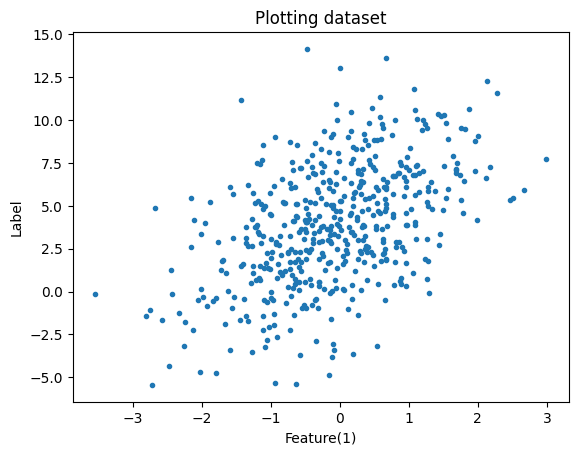

In [174]:
f = np.array(features[:, 0].detach().numpy())
l = np.array(labels.detach().numpy())

# Plot the data
plt.plot(f, l, marker=".", linewidth=0)

# Add labels and a title
plt.xlabel("Feature(1)")
plt.ylabel("Label")
plt.title("Plotting dataset")

# Display the plot
plt.show()

In [175]:
def data_iter(features, labels, batch_size):
    num_rows = features.shape[0]
    indices = torch.randperm(num_rows)
    
    i = 0
    while i<features.shape[0]:
        selected_indices = indices[i:min(i+batch_size, num_rows-1)]
        yield features[selected_indices], labels[selected_indices]
        i += batch_size

In [176]:
for f, l in data_iter(features, labels, 32):
    break

In [177]:
def l2_loss(y: torch.Tensor, y_hat: torch.Tensor):
    return ((y-y_hat)**2).mean()

In [178]:
## model params

w = torch.normal(0, 0.01, size=(2,), requires_grad=True)
b = torch.zeros((1,), requires_grad=True)
print(w.shape, b.shape)

torch.Size([2]) torch.Size([1])


In [179]:
def sgd(params, lr): # not worrying about batch size as in loss we take mean
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad
            param.grad.zero_()

In [180]:
def net(params, features, labels):
    y_hat = torch.einsum("f,bf->b", params[0], features) + params[1]
    return y_hat

In [183]:
epochs = 100

params = [w, b]

for epoch in range(epochs):
    for X, y in data_iter(features, labels, 32):
        y_hat = net(params, features, labels)
        loss = l2_loss(labels, y_hat)
        loss.backward()
        sgd(params, 0.03)

    with torch.no_grad():
        train_l = l2_loss(net(params, features, labels), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.000094
epoch 2, loss 0.000094
epoch 3, loss 0.000094
epoch 4, loss 0.000094
epoch 5, loss 0.000094
epoch 6, loss 0.000094
epoch 7, loss 0.000094
epoch 8, loss 0.000094
epoch 9, loss 0.000094
epoch 10, loss 0.000094
epoch 11, loss 0.000094
epoch 12, loss 0.000094
epoch 13, loss 0.000094
epoch 14, loss 0.000094
epoch 15, loss 0.000094
epoch 16, loss 0.000094
epoch 17, loss 0.000094
epoch 18, loss 0.000094
epoch 19, loss 0.000094
epoch 20, loss 0.000094
epoch 21, loss 0.000094
epoch 22, loss 0.000094
epoch 23, loss 0.000094
epoch 24, loss 0.000094
epoch 25, loss 0.000094
epoch 26, loss 0.000094
epoch 27, loss 0.000094
epoch 28, loss 0.000094
epoch 29, loss 0.000094
epoch 30, loss 0.000094
epoch 31, loss 0.000094
epoch 32, loss 0.000094
epoch 33, loss 0.000094
epoch 34, loss 0.000094
epoch 35, loss 0.000094
epoch 36, loss 0.000094
epoch 37, loss 0.000094
epoch 38, loss 0.000094
epoch 39, loss 0.000094
epoch 40, loss 0.000094
epoch 41, loss 0.000094
epoch 42, loss 0.000094
e